# Final Project Notebook

Academic notebook for predicting the future price direction of financial assets with machine learning and a trading backtest.

This notebook starts with: setup, data collection, data loading, and data processing. The modeling sections come after the data is validated, so every later result is tied to a clear and reproducible dataset.


Predicting BUY / HOLD / SELL direction for a future horizon.
It combines stock OHLCV prices with broader market and macro / alternative signals, then compares two model families, LSTM and XGBoost.

The full workflow is:

1. Set up the Python project environment.
2. Load the project configuration.
3. Collect historical stock, benchmark, macro / alternative, and earnings data.
4. Process the raw data into a supervised learning table.
5. Validate date coverage, merged external features, labels, and missing values.
6. Train and compare LSTM and XGBoost models.
7. Evaluate statistical metrics and financial backtest metrics after costs.
8. Run inference for a sample ticker and list demo-ready output files.


## 1. Setup

This cell finds the project root, loads `configs/config.yaml`, and derives notebook defaults from the same configuration used by training, inference, and the UI.

The key point is that `HORIZON` is not hard-coded here. It uses `default_prediction_horizon` from the config, so if the config changes from 21 trading days to another trained horizon, the notebook follows automatically. `SAMPLE_TICKER` also comes from the first ticker in the configured training universe.

Training uses the device setting from config. `device: "auto"` chooses CUDA on NVIDIA, MPS/Metal on Apple Silicon Mac, and CPU otherwise.

Processed datasets are cached under `data/cache/` after the first build. Keep `use_dataset_cache: true` for faster reruns. Set `force_rebuild_dataset_cache: true` in config when tickers, dates, macro sources, thresholds, or feature logic changed.

Keep `RUN_TRAINING = True` for a full fresh run. Set `REBUILD_DATASET = True` when you want the notebook data-preview cell to force a new data download and rebuild only the processed dataset before training.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
import yaml

# Find the project root so the notebook works from Colab, Jupyter, or the notebooks folder.
ROOT = Path.cwd()
if not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

# Load the same project configuration used by train.py, predict.py, and the UI.
config_path = ROOT / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

available_horizons = [int(h) for h in config.get('prediction_horizons', [config.get('prediction_horizon', 21)])]
HORIZON = int(config.get('default_prediction_horizon', available_horizons[0]))
if HORIZON not in available_horizons:
    HORIZON = available_horizons[0]

SAMPLE_TICKER = str(config['tickers'][0])
RUN_TRAINING = True
INSTALL_REQUIREMENTS = True
REBUILD_DATASET = False

print(f'Project root: {ROOT}')
print(f'Config file: {config_path}')
print(f'Configured horizons: {available_horizons}')
print(f'Selected notebook horizon: {HORIZON} trading days')
print(f'Sample ticker from config: {SAMPLE_TICKER}')
print(f'Rebuild dataset first: {REBUILD_DATASET}')


Project root: c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction
Config file: c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\configs\config.yaml
Configured horizons: [1, 5, 21, 126, 252, 1260, 2520]
Selected notebook horizon: 21 trading days
Sample ticker from config: AAPL
Rebuild dataset first: False


In [2]:
def run_command(args, check=True):
    print('\n$ ' + ' '.join(str(a) for a in args))
    result = subprocess.run([str(a) for a in args], cwd=ROOT, text=True)
    if check and result.returncode != 0:
        raise RuntimeError(f'Command failed with exit code {result.returncode}: {args}')
    return result.returncode

if INSTALL_REQUIREMENTS:
    run_command([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])



$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m pip install -r requirements.txt


## 2. Project Configuration

The configuration file is `configs/config.yaml` in the project root. It is the single source of truth for the data universe and modeling setup. The notebook loaded it in the setup cell, so the displayed horizon, sample ticker, data dates, benchmark, macro sources, and 100-stock universe all come from the same config used by the scripts.

The current setup uses data from `2005-01-01`, which gives enough history for long-horizon labels. The training universe is configured with 100 large/liquid US-listed stocks across sectors. The stock universe is joined with `SPY` benchmark features and macro / alternative proxies for volatility, interest rates, and dollar strength.

The horizon is measured in trading days. The configured horizons are `1`, `5`, `21`, `126`, `252`, `1260`, and `2520`, corresponding approximately to 1 day, 1 week, 1 month, 6 months, 1 year, 5 years, and 10 years.


In [3]:
source_rows = []
for ticker in config['tickers']:
    source_rows.append({'source_type': 'stock_price', 'name': ticker, 'ticker': ticker})
source_rows.append({'source_type': 'benchmark', 'name': 'market benchmark', 'ticker': config['benchmark_ticker']})
for name, ticker in config.get('macro_tickers', {}).items():
    source_rows.append({'source_type': 'macro_or_alternative', 'name': name, 'ticker': ticker})

print(f'Configuration loaded from: {config_path}')
print(f"Configured stock universe size: {len(config['tickers'])} tickers")
print(f"Configured start date: {config['start_date']}")
print(f"Configured end date: {config['end_date'] or 'latest available'}")
print(f"Available horizons: {available_horizons}")
print(f"Selected notebook horizon: {HORIZON} trading days")
print(f"Dataset cache enabled: {config.get('use_dataset_cache', True)}")
print(f"Force cache rebuild: {config.get('force_rebuild_dataset_cache', False)}")
print(f"Training device setting: {config.get('device', 'auto')}")
print(f"Buy threshold: {float(config['buy_threshold']):.2%}; sell threshold: {float(config['sell_threshold']):.2%}")
display(pd.DataFrame(source_rows))


Configuration loaded from: c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\configs\config.yaml
Configured stock universe size: 100 tickers
Configured start date: 2005-01-01
Configured end date: latest available
Available horizons: [1, 5, 21, 126, 252, 1260, 2520]
Selected notebook horizon: 21 trading days
Dataset cache enabled: True
Force cache rebuild: False
Training device setting: mps
Buy threshold: 3.00%; sell threshold: -3.00%


,source_type,name,ticker
0,stock_price,AAPL,AAPL
1,stock_price,MSFT,MSFT
2,stock_price,NVDA,NVDA
3,stock_price,AMZN,AMZN
4,stock_price,META,META
...,...,...,...
99,stock_price,WM,WM
100,benchmark,market benchmark,SPY
101,macro_or_alternative,vix,^VIX
102,macro_or_alternative,treasury_10y,^TNX


## 3. Data Collection Design

The raw data is collected by `src/data_download.py` through Yahoo Finance using `yfinance`.

Exact sources used in this project:

- Stock OHLCV history: daily Open, High, Low, Close, Adjusted Close, and Volume for each configured stock ticker.
- Benchmark history: `SPY`, used to add broad market return and volatility context.
- Macro / alternative market data: `^VIX` for market fear / volatility, `^TNX` as a 10-year Treasury yield proxy, and `DX-Y.NYB` for dollar strength.
- Earnings dates: available earnings calendar fields from Yahoo Finance, used only when the provider returns them.

These sources satisfy the requirement to merge historical financial data with non-stock-specific alternative or macro signals. No private API key is required, and the repository does not need to store secrets.


## 4. Data Loading and Processing

The shared pipeline in `src/pipeline.py` builds the supervised learning dataset in this order:

1. Download benchmark data and macro / alternative data for the configured date range.
2. For each stock ticker, download daily OHLCV history.
3. Add technical indicators from price and volume, including returns, moving averages, RSI, MACD, ATR, Bollinger Band features, and realized volatility.
4. Join benchmark features by date.
5. Join macro / alternative features by date and forward-fill known values.
6. Add earnings proximity and latest known earnings surprise fields where available.
7. Create `future_return` and `signal_label` for the selected horizon.
8. Drop rows that are not usable for training because rolling indicators or future labels are missing.
9. Save the processed supervised dataset to `data/cache/full_dataset_h{horizon}.csv` so the next run can reuse it.

Label mining / label creation: the label is mined from the future price movement after the selected horizon. The horizon is in trading days, so horizon 21 means 21 market sessions later, about one month. The notebook compares the adjusted close 21 trading days later to today's adjusted close. If the future return is at least `buy_threshold` then `signal_label = 2` meaning BUY. If the future return is at most `sell_threshold` then `signal_label = 0` meaning SELL. Otherwise `signal_label = 1` meaning HOLD. This creates supervised labels from historical data without manually labeling examples.

What is each row? Each row is one stock on one trading date. It contains that stock's price/volume data for the date, engineered technical indicators known by that date, joined benchmark and macro values for the same date, earnings context, and the future label used for training. The row is the model's learning example: features are the inputs, while `future_return` and `signal_label` are the targets.


In [ ]:
import importlib

from src.features import get_feature_columns
from src.regression import add_model_target, resolve_target_config
import src.pipeline as pipeline

# Reload because notebooks can keep an older imported src.pipeline in memory.
pipeline = importlib.reload(pipeline)
build_or_load_dataset_for_tickers = pipeline.build_or_load_dataset_for_tickers

cache_dir = ROOT / 'data' / 'cache'
cache_dir.mkdir(parents=True, exist_ok=True)
dataset_cache_path = cache_dir / f'full_dataset_h{HORIZON}.parquet'

full_df, feature_columns = build_or_load_dataset_for_tickers(
    tickers=config['tickers'],
    benchmark_ticker=config['benchmark_ticker'],
    start_date=config['start_date'],
    end_date=config['end_date'],
    prediction_horizon=HORIZON,
    buy_threshold=float(config['buy_threshold']),
    sell_threshold=float(config['sell_threshold']),
    macro_tickers=config.get('macro_tickers'),
    cache_path=dataset_cache_path,
    use_cache=bool(config.get('use_dataset_cache', True)),
    force_rebuild=bool(config.get('force_rebuild_dataset_cache', False)) or REBUILD_DATASET,
    regime_normalization_window=int(config.get('regime_normalization_window', 252)),
    exclude_market_wide_features=bool(config.get('exclude_market_wide_features', True)),
)

# Attach the market-excess training target and its volatility scale.
target_config = resolve_target_config(config.get('regression_target'))
full_df = add_model_target(full_df, HORIZON, target_config)

df = full_df.reset_index().rename(columns={'index': 'Date'})
if 'Date' not in df.columns:
    df = df.rename(columns={df.columns[0]: 'Date'})
df['Date'] = pd.to_datetime(df['Date'])

print(f'Dataset cache: {dataset_cache_path}')
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns):,}')
print(f'Feature columns: {len(feature_columns):,}')
print(f"Modelled component: {'future_excess_return' if target_config['mode'] == 'market_excess' else 'future_return'}")
display(df.head())

## 5. Data Validation Test

Before training, the notebook checks the first project requirement directly: the processed dataset must contain at least three years of usable history and must include merged external macro / alternative features. It also checks that the supervised labels exist and that selected model features are not missing after processing.


In [5]:
date_coverage_years = (df['Date'].max() - df['Date'].min()).days / 365.25
macro_columns = [column for column in df.columns if column.startswith('macro_')]
benchmark_columns = [column for column in df.columns if column.startswith('benchmark_')]
label_values = sorted(df['signal_label'].dropna().astype(int).unique().tolist())
feature_missing_rate = df[feature_columns].isna().mean().sort_values(ascending=False).head(10)

validation_summary = pd.DataFrame(
    [
        {'check': 'usable rows', 'value': len(df), 'passes': len(df) > 0},
        {'check': 'start date', 'value': str(df['Date'].min().date()), 'passes': True},
        {'check': 'end date', 'value': str(df['Date'].max().date()), 'passes': True},
        {'check': 'coverage years', 'value': round(date_coverage_years, 2), 'passes': date_coverage_years >= 3.0},
        {'check': 'stock tickers', 'value': df['Ticker'].nunique(), 'passes': df['Ticker'].nunique() >= 1},
        {'check': 'macro / alternative columns', 'value': len(macro_columns), 'passes': len(macro_columns) >= 3},
        {'check': 'benchmark columns', 'value': len(benchmark_columns), 'passes': len(benchmark_columns) >= 1},
        {'check': 'labels present', 'value': label_values, 'passes': set(label_values).issubset({0, 1, 2}) and len(label_values) > 0},
        {'check': 'feature missing values', 'value': float(df[feature_columns].isna().sum().sum()), 'passes': df[feature_columns].isna().sum().sum() == 0},
    ]
)

display(validation_summary)
display(feature_missing_rate.rename('missing_rate').reset_index().rename(columns={'index': 'feature'}))

assert date_coverage_years >= 3.0, 'Dataset must contain at least 3 years of usable rows.'
assert len(macro_columns) >= 3, 'Dataset must include macro / alternative features.'
assert len(benchmark_columns) >= 1, 'Dataset must include benchmark features.'
assert df[feature_columns].isna().sum().sum() == 0, 'Feature matrix contains missing values.'
assert set(label_values).issubset({0, 1, 2}) and len(label_values) > 0, 'Labels must be BUY/HOLD/SELL ids.'


,check,value,passes
0,usable rows,488513,True
1,start date,2005-10-17,True
2,end date,2026-06-05,True
3,coverage years,20.63,True
4,stock tickers,98,True
5,macro / alternative columns,12,True
6,benchmark columns,3,True
7,labels present,"[0, 1, 2]",True
8,feature missing values,0.0,True


,feature,missing_rate
0,return_1d,0.0
1,log_return_1d,0.0
2,return_5d,0.0
3,return_10d,0.0
4,return_20d,0.0
5,return_60d,0.0
6,sma_20,0.0
7,ema_20,0.0
8,price_to_sma_20,0.0
9,sma_50,0.0


## 6. EDA

This section inspects the processed supervised dataset before any model training. The goal is to verify data quality, date coverage, ticker coverage, target balance, return behavior, macro/benchmark signals, and possible feature relationships with the target.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Use the processed dataframe created in the data-loading cell. Re-load only if needed.
if 'df' not in globals() or df.empty:
    dataset_path = ROOT / 'data' / 'processed' / f'full_dataset_h{HORIZON}.csv'
    df = pd.read_csv(dataset_path)

if 'Date' not in df.columns:
    df = df.rename(columns={df.columns[0]: 'Date'})
df['Date'] = pd.to_datetime(df['Date'])

label_names = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
df['signal_name'] = df['signal_label'].map(label_names)

numeric_columns = [column for column in df.columns if pd.api.types.is_numeric_dtype(df[column])]
macro_columns = [column for column in df.columns if column.startswith('macro_')]
benchmark_columns = [column for column in df.columns if column.startswith('benchmark_')]
technical_columns = [
    column for column in numeric_columns
    if column not in {'signal_label', 'future_return'}
    and not column.startswith('macro_')
    and not column.startswith('benchmark_')
    and column not in {'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'}
]

eda_summary = pd.DataFrame([
    {'metric': 'rows', 'value': f'{len(df):,}'},
    {'metric': 'columns', 'value': f'{len(df.columns):,}'},
    {'metric': 'tickers', 'value': f'{df["Ticker"].nunique():,}'},
    {'metric': 'start date', 'value': str(df['Date'].min().date())},
    {'metric': 'end date', 'value': str(df['Date'].max().date())},
    {'metric': 'date coverage years', 'value': round((df['Date'].max() - df['Date'].min()).days / 365.25, 2)},
    {'metric': 'numeric features', 'value': f'{len(numeric_columns):,}'},
    {'metric': 'technical columns', 'value': f'{len(technical_columns):,}'},
    {'metric': 'benchmark columns', 'value': f'{len(benchmark_columns):,}'},
    {'metric': 'macro columns', 'value': f'{len(macro_columns):,}'},
    {'metric': 'selected horizon', 'value': f'{HORIZON} trading days'},
])
display(eda_summary)


,metric,value
0,rows,"488,513"
1,columns,70
2,tickers,98
3,start date,2005-10-17
4,end date,2026-06-05
5,date coverage years,20.63
6,numeric features,67
7,technical columns,44
8,benchmark columns,3
9,macro columns,12


### Data Sample

Each row is one ticker on one trading date. Feature columns are the model inputs. `future_return` and `signal_label` are the supervised targets created from future price movement.


In [7]:
sample_columns = [
    'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
    'return_1d', 'sma_20', 'rsi_14',
    'benchmark_return_1d', 'benchmark_volatility_20d',
    'macro_vix_close', 'macro_treasury_10y_close', 'macro_usd_index_close',
    'future_return', 'signal_label', 'signal_name'
]
sample_columns = [column for column in sample_columns if column in df.columns]
display(df[sample_columns].head(10))


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,return_1d,sma_20,rsi_14,benchmark_return_1d,benchmark_volatility_20d,macro_vix_close,macro_treasury_10y_close,macro_usd_index_close,future_return,signal_label,signal_name
0,2005-10-17,UNP,17.307501,17.432501,17.090000,17.362499,11.388841,2729200,0.003323,11.463538,55.528105,0.003708,0.006466,14.67,4.489,89.800003,0.025918,1,HOLD
1,2005-10-17,AMD,21.360001,21.600000,21.219999,21.370001,21.370001,5727800,0.008495,23.304000,37.903223,0.003708,0.006466,14.67,4.489,89.800003,0.193262,2,BUY
2,2005-10-17,COST,46.250000,46.619999,46.029999,46.610001,31.508785,2460200,0.003228,29.638599,77.496180,0.003708,0.006466,14.67,4.489,89.800003,0.056640,2,BUY
3,2005-10-17,MU,12.970000,13.050000,12.830000,13.010000,12.686534,5540300,0.010878,12.324759,63.481950,0.003708,0.006466,14.67,4.489,89.800003,0.026903,1,HOLD
4,2005-10-17,WMT,15.093333,15.096667,14.946667,15.080000,9.986643,29382900,0.004441,9.684218,80.747215,0.003708,0.006466,14.67,4.489,89.800003,0.078249,2,BUY
5,2005-10-17,GOOG,7.409727,7.601508,7.336501,7.596526,7.530136,303802474,0.029918,7.640334,42.099710,0.003708,0.006466,14.67,4.489,89.800003,0.287869,2,BUY
6,2005-10-17,CMCSA,8.497345,8.559825,8.441112,8.481724,5.612775,27215542,-0.005495,5.899927,23.428587,0.003708,0.006466,14.67,4.489,89.800003,-0.025046,1,HOLD
7,2005-10-17,MSFT,24.680000,24.690001,24.440001,24.530001,16.978729,46924400,-0.005675,17.349728,35.888531,0.003708,0.006466,14.67,4.489,89.800003,0.124363,2,BUY
8,2005-10-17,JPM,34.209999,34.330002,33.779999,34.000000,19.903994,8469300,-0.002348,19.731949,56.790934,0.003708,0.006466,14.67,4.489,89.800003,0.109706,2,BUY
9,2005-10-17,CSCO,17.230000,17.370001,17.139999,17.170000,11.008810,34345300,-0.005791,11.330677,36.318321,0.003708,0.006466,14.67,4.489,89.800003,0.005825,1,HOLD


### Data Quality Checks

This checks missing values, duplicates, non-finite numeric values, and row count distribution across tickers.


In [8]:
missing_report = (
    df.isna().mean()
    .sort_values(ascending=False)
    .rename('missing_rate')
    .reset_index()
    .rename(columns={'index': 'column'})
)
missing_report['missing_count'] = missing_report['column'].map(df.isna().sum())

finite_numeric = df[numeric_columns].replace([np.inf, -np.inf], np.nan)
non_finite_count = int(finite_numeric.isna().sum().sum() - df[numeric_columns].isna().sum().sum())
duplicate_count = int(df.duplicated(subset=['Date', 'Ticker']).sum())
rows_per_ticker = df.groupby('Ticker').size().rename('rows').sort_values()

quality_summary = pd.DataFrame([
    {'check': 'duplicate Date/Ticker rows', 'value': duplicate_count},
    {'check': 'non-finite numeric values', 'value': non_finite_count},
    {'check': 'minimum rows per ticker', 'value': int(rows_per_ticker.min())},
    {'check': 'median rows per ticker', 'value': int(rows_per_ticker.median())},
    {'check': 'maximum rows per ticker', 'value': int(rows_per_ticker.max())},
])

display(quality_summary)
display(missing_report.head(20))


,check,value
0,duplicate Date/Ticker rows,0
1,non-finite numeric values,0
2,minimum rows per ticker,1579
3,median rows per ticker,5191
4,maximum rows per ticker,5191


,column,missing_rate,missing_count
0,Date,0.0,0
1,Open,0.0,0
2,High,0.0,0
3,Low,0.0,0
4,Close,0.0,0
5,Adj Close,0.0,0
6,Volume,0.0,0
7,Ticker,0.0,0
8,return_1d,0.0,0
9,log_return_1d,0.0,0


### Ticker and Date Coverage

The model should not be trained blindly if some tickers have much shorter histories than others. This table exposes those differences.


In [9]:
coverage_by_ticker = (
    df.groupby('Ticker')
    .agg(
        rows=('Ticker', 'size'),
        start_date=('Date', 'min'),
        end_date=('Date', 'max'),
        mean_future_return=('future_return', 'mean'),
        volatility_future_return=('future_return', 'std'),
    )
    .reset_index()
)
coverage_by_ticker['start_date'] = coverage_by_ticker['start_date'].dt.date
coverage_by_ticker['end_date'] = coverage_by_ticker['end_date'].dt.date
coverage_by_ticker.sort_values('rows').head(15)


,Ticker,rows,start_date,end_date,mean_future_return,volatility_future_return
87,UBER,1579,2020-02-25,2026-06-05,0.021436,0.131255
11,ANET,2819,2015-03-23,2026-06-05,0.034662,0.119551
97,ZTS,3157,2013-11-14,2026-06-05,0.009353,0.071347
1,ABBV,3178,2013-10-16,2026-06-05,0.016532,0.073090
67,PANW,3290,2013-05-08,2026-06-05,0.029674,0.115868
64,NOW,3299,2013-04-18,2026-06-05,0.021695,0.104027
57,META,3326,2013-03-07,2026-06-05,0.025381,0.104154
85,TSLA,3810,2011-04-12,2026-06-05,0.045637,0.185649
12,AVGO,4035,2010-05-21,2026-06-05,0.033897,0.097918
91,V,4384,2008-12-31,2026-06-05,0.018286,0.059283


### Target Label Balance

A useful classification dataset needs enough examples of SELL, HOLD, and BUY. Severe imbalance can make accuracy misleading.


,label,count,share
0,SELL,122784,0.251342
1,HOLD,168663,0.345258
2,BUY,197066,0.403400


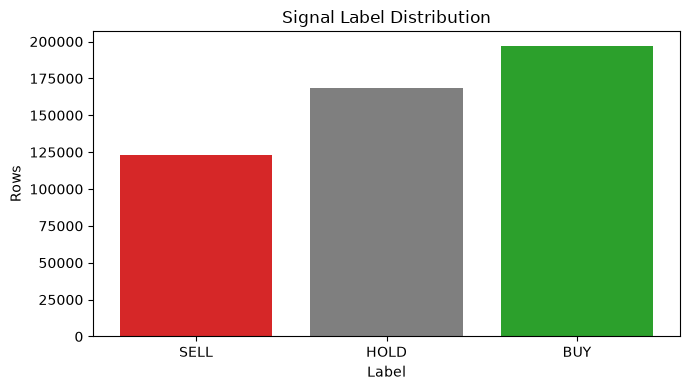

In [11]:
label_counts = (
    df['signal_name']
    .value_counts()
    .reindex(['SELL', 'HOLD', 'BUY'])
    .fillna(0)
    .rename_axis('label')
    .reset_index(name='count')
)
label_counts['share'] = label_counts['count'] / label_counts['count'].sum()
display(label_counts)

plt.figure(figsize=(7, 4))
plt.bar(label_counts['label'], label_counts['count'], color=['#d62728', '#7f7f7f', '#2ca02c'])
plt.title('Signal Label Distribution')
plt.xlabel('Label')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()


signal_name,SELL,HOLD,BUY
year,,,
2017,3197,10122,11024
2018,7516,8696,8130
2019,4448,8476,11519
2020,6376,6726,11653
2021,5618,8493,10585
2022,9266,6583,8749
2023,6199,8154,10146
2024,6019,8621,10056
2025,6808,7895,9789


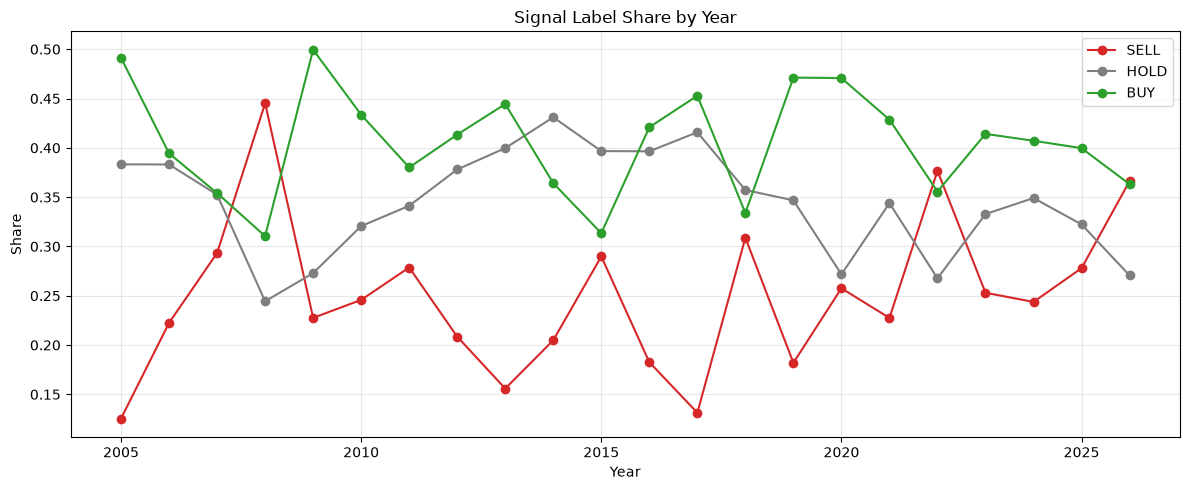

In [12]:
label_by_year = (
    df.assign(year=df['Date'].dt.year)
    .groupby(['year', 'signal_name'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['SELL', 'HOLD', 'BUY'], fill_value=0)
)
label_by_year_share = label_by_year.div(label_by_year.sum(axis=1), axis=0)

display(label_by_year.tail(10))

plt.figure(figsize=(12, 5))
for label, color in [('SELL', '#d62728'), ('HOLD', '#7f7f7f'), ('BUY', '#2ca02c')]:
    if label in label_by_year_share:
        plt.plot(label_by_year_share.index, label_by_year_share[label], marker='o', label=label, color=color)
plt.title('Signal Label Share by Year')
plt.xlabel('Year')
plt.ylabel('Share')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Future Return Distribution

This shows the regression target distribution and whether the selected horizon creates extreme or skewed future-return values.


,future_return
count,488513.000000
mean,0.015037
std,0.086997
min,-0.749935
1%,-0.214210
5%,-0.115293
25%,-0.030315
50%,0.014544
75%,0.058250
95%,0.146238


C:\Users\יהונתן סגל\AppData\Local\Temp\ipykernel_11380\1668648906.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['future_return'].dropna(), vert=False)


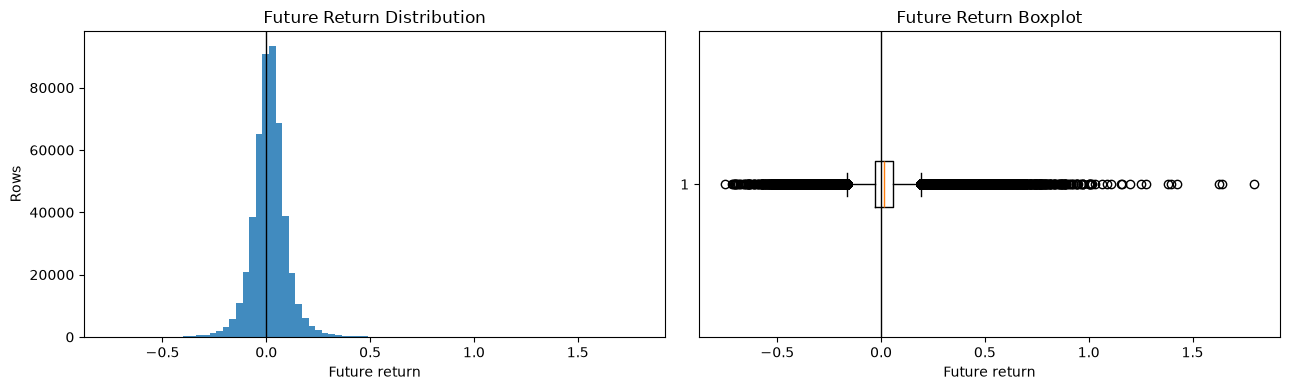

In [13]:
future_return_summary = df['future_return'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame()
display(future_return_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['future_return'].dropna(), bins=80, color='#1f77b4', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Future Return Distribution')
axes[0].set_xlabel('Future return')
axes[0].set_ylabel('Rows')

axes[1].boxplot(df['future_return'].dropna(), vert=False)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Future Return Boxplot')
axes[1].set_xlabel('Future return')
plt.tight_layout()
plt.show()


### Price and Return Time Series

A small ticker sample helps verify that adjusted prices and returns look reasonable through time.


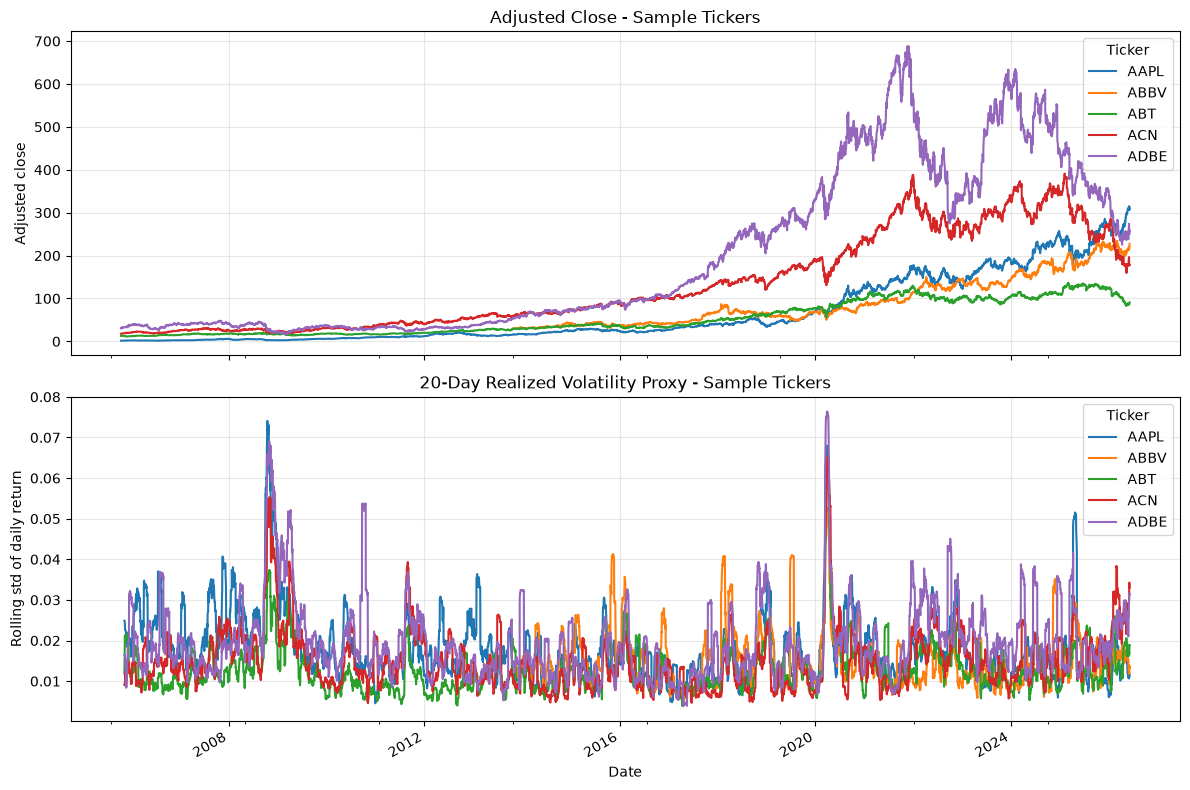

In [14]:
sample_tickers = sorted(df['Ticker'].dropna().unique())[:5]
price_pivot = df[df['Ticker'].isin(sample_tickers)].pivot_table(index='Date', columns='Ticker', values='Adj Close')
return_pivot = df[df['Ticker'].isin(sample_tickers)].pivot_table(index='Date', columns='Ticker', values='return_1d')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
price_pivot.plot(ax=axes[0])
axes[0].set_title('Adjusted Close - Sample Tickers')
axes[0].set_ylabel('Adjusted close')
axes[0].grid(True, alpha=0.3)

return_pivot.rolling(20).std().plot(ax=axes[1])
axes[1].set_title('20-Day Realized Volatility Proxy - Sample Tickers')
axes[1].set_ylabel('Rolling std of daily return')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Benchmark and Macro Context

These plots check whether the joined external data is populated and moves through time as expected.


,count,mean,std,min,25%,50%,75%,max
benchmark_return_1d,5191.0,0.000498,0.012105,-0.109423,-0.003933,0.000717,0.005896,0.145198
benchmark_volatility_20d,5191.0,0.009959,0.007039,0.002010,0.005879,0.008262,0.011670,0.060422
macro_vix_close,5191.0,19.392368,8.649629,9.140000,13.700000,17.070000,22.379999,82.690002
macro_treasury_10y_close,5191.0,2.943768,1.134910,0.499000,2.023500,2.815000,3.939500,5.248000
macro_usd_index_close,5191.0,90.595562,9.746997,71.330002,81.185001,92.510002,98.174999,114.110001


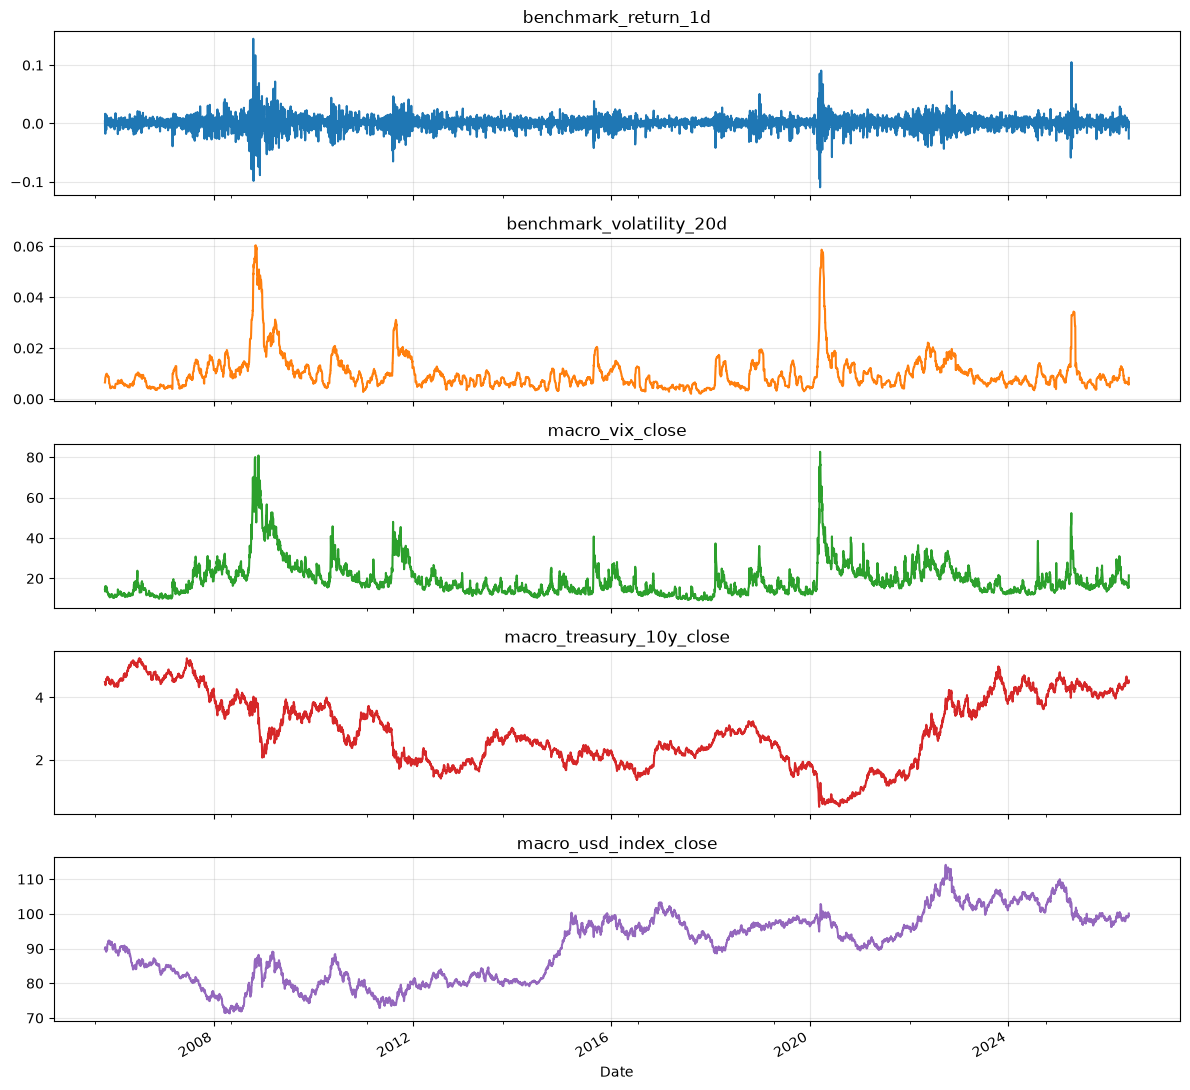

In [15]:
context_columns = [
    'benchmark_return_1d', 'benchmark_volatility_20d',
    'macro_vix_close', 'macro_treasury_10y_close', 'macro_usd_index_close'
]
context_columns = [column for column in context_columns if column in df.columns]
context_df = df[['Date', *context_columns]].drop_duplicates('Date').sort_values('Date')

display(context_df[context_columns].describe().T)

if context_columns:
    axes = context_df.set_index('Date')[context_columns].plot(subplots=True, figsize=(12, 2.2 * len(context_columns)), legend=False)
    if not isinstance(axes, np.ndarray):
        axes = np.asarray([axes])
    for ax, column in zip(axes.flatten(), context_columns):
        ax.set_title(column)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Feature Relationship With the Target

Simple correlations do not prove predictability, but they are useful for sanity-checking feature direction and identifying leakage-like surprises.


,feature,corr_with_future_return
0,macro_treasury_10y_volatility_20d,0.090230
1,volatility_60d,0.078391
2,bb_width_20,0.070687
3,volatility_20d,0.067935
4,macro_vix_close,0.065740
5,volatility_10d,0.065687
6,atr_14,-0.061275
7,macro_treasury_10y_close,-0.047989
8,price_to_sma_50,-0.047451
9,sma_20_above_50,-0.044388


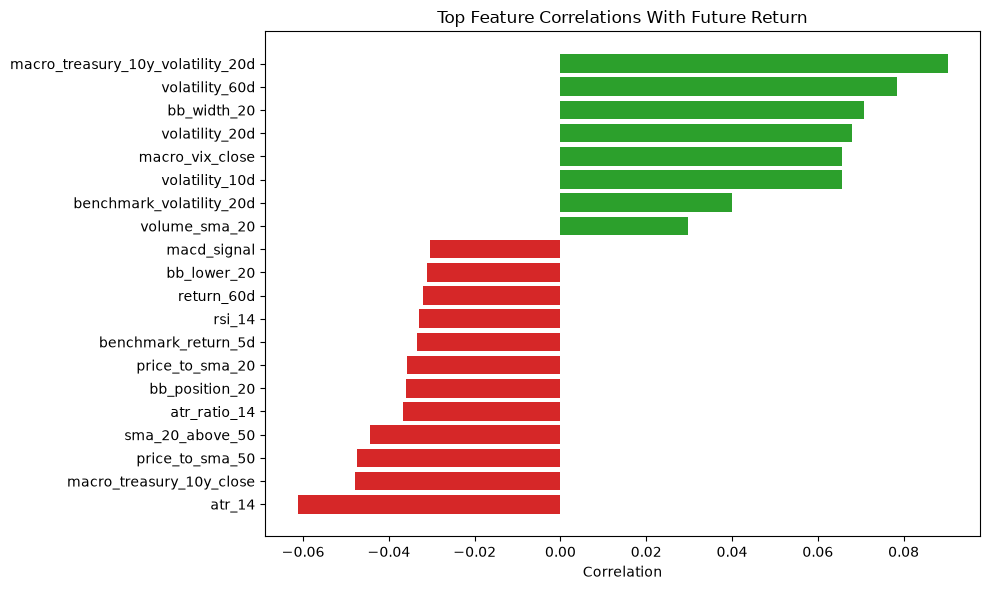

In [16]:
candidate_features = [column for column in feature_columns if column in df.columns and column in numeric_columns]
correlations = (
    df[candidate_features + ['future_return']]
    .corr(numeric_only=True)['future_return']
    .drop('future_return')
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

top_correlations = correlations.head(20).rename('corr_with_future_return').reset_index().rename(columns={'index': 'feature'})
display(top_correlations)

plt.figure(figsize=(10, 6))
plot_data = top_correlations.sort_values('corr_with_future_return')
colors = ['#d62728' if value < 0 else '#2ca02c' for value in plot_data['corr_with_future_return']]
plt.barh(plot_data['feature'], plot_data['corr_with_future_return'], color=colors)
plt.title('Top Feature Correlations With Future Return')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()


,future_return,return_1d,return_5d,return_20d,volatility_20d,rsi_14,macd,volume_ratio_20,benchmark_return_1d,benchmark_volatility_20d,macro_vix_close,macro_treasury_10y_close,macro_usd_index_close
future_return,1.000000,-0.019710,-0.027367,-0.026723,0.067935,-0.032921,-0.028910,0.001506,-0.023841,0.040045,0.065740,-0.047989,0.025934
return_1d,-0.019710,1.000000,0.427609,0.212001,0.029227,0.219724,0.030381,-0.017861,0.584293,0.006735,-0.079572,-0.004341,0.000268
return_5d,-0.027367,0.427609,1.000000,0.476781,0.040703,0.495730,0.185295,-0.073980,0.231148,-0.020108,-0.149763,-0.013073,-0.003532
return_20d,-0.026723,0.212001,0.476781,1.000000,-0.055668,0.697408,0.502458,-0.060647,0.108823,-0.209074,-0.241243,-0.028629,-0.007379
volatility_20d,0.067935,0.029227,0.040703,-0.055668,1.000000,-0.089730,-0.102228,-0.002437,0.006134,0.629774,0.565223,-0.011297,-0.017722
rsi_14,-0.032921,0.219724,0.495730,0.697408,-0.089730,1.000000,0.406820,-0.081274,0.119711,-0.126511,-0.214739,-0.035644,-0.011007
macd,-0.028910,0.030381,0.185295,0.502458,-0.102228,0.406820,1.000000,-0.031897,0.010344,-0.160387,-0.152241,-0.008722,0.047405
volume_ratio_20,0.001506,-0.017861,-0.073980,-0.060647,-0.002437,-0.081274,-0.031897,1.000000,-0.056133,-0.023518,0.043585,0.005699,-0.001125
benchmark_return_1d,-0.023841,0.584293,0.231148,0.108823,0.006134,0.119711,0.010344,-0.056133,1.000000,0.004963,-0.142864,-0.003962,0.003542
benchmark_volatility_20d,0.040045,0.006735,-0.020108,-0.209074,0.629774,-0.126511,-0.160387,-0.023518,0.004963,1.000000,0.868036,-0.070108,-0.046057


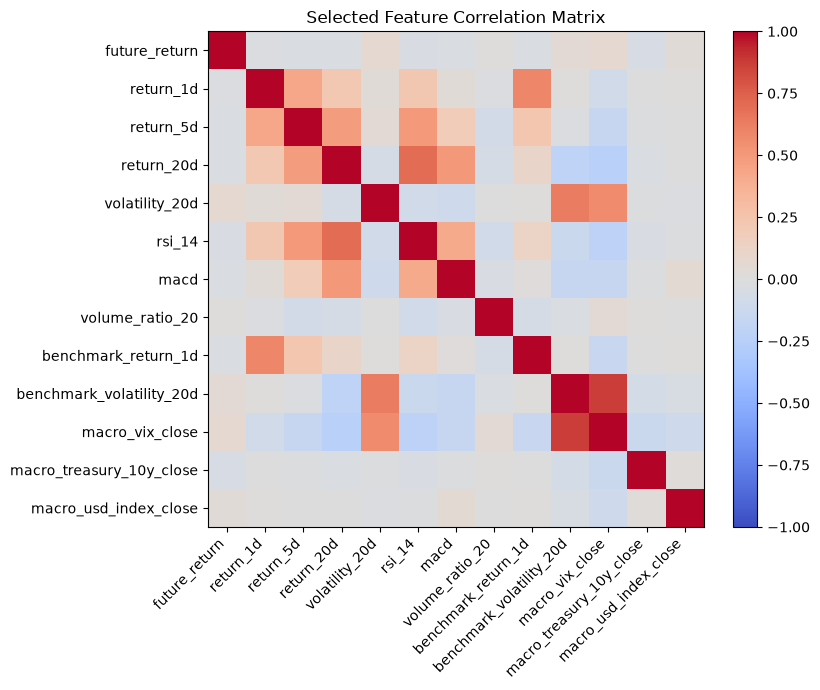

In [17]:
correlation_columns = [
    'future_return', 'return_1d', 'return_5d', 'return_20d', 'volatility_20d',
    'rsi_14', 'macd', 'volume_ratio_20',
    'benchmark_return_1d', 'benchmark_volatility_20d',
    'macro_vix_close', 'macro_treasury_10y_close', 'macro_usd_index_close'
]
correlation_columns = [column for column in correlation_columns if column in df.columns]
corr_matrix = df[correlation_columns].corr(numeric_only=True)

display(corr_matrix)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Selected Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 7. Source Code Validation

These checks confirm that the scripts and `src` package compile. The unit test validates the data-processing contract with synthetic data, so it can run without live downloads.


In [18]:
run_command([
    sys.executable, '-m', 'py_compile',
    'train.py', 'train_xgboost.py', 'train_all_models.py',
    'compare_results.py', 'compare_models.py', 'evaluate_saved_model.py', 'predict.py'
])
run_command([sys.executable, '-m', 'compileall', 'src'])
run_command([
    sys.executable, '-m', 'unittest',
    'tests.test_data_pipeline_validation',
    'tests.test_device_selection',
    'tests.test_training_workflow',
])



$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m py_compile train.py train_xgboost.py train_all_models.py compare_results.py compare_models.py evaluate_saved_model.py predict.py

$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m compileall src

$ c:\Users\יהונתן סגל\Projects\B.Sc - SISE\D - Forth year\Semester B\algo-trading-lstm-stock-prediction\.venv\Scripts\python.exe -m unittest tests.test_data_pipeline_validation tests.test_device_selection tests.test_training_workflow


0

## Feature Engineering Summary

The shared pipeline builds technical indicators, benchmark features, macro / alternative features, earnings features, and future-return labels. The split used later is chronological to avoid training on future data.


## LSTM Training

The LSTM is the sequential model. It uses rolling windows and has two heads: one for BUY / HOLD / SELL classification and one for future return regression.

In [ ]:
if RUN_TRAINING:
    run_command([sys.executable, 'train.py', '--horizon', HORIZON])
else:
    print('Skipping LSTM training because RUN_TRAINING = False')

## XGBoost Training

XGBoost is the second model family. It uses the same dataset pipeline and chronological split, then saves a classifier, regressor, metrics, predictions, and backtest results.

In [ ]:
if RUN_TRAINING:
    run_command([sys.executable, 'train_xgboost.py', '--horizon', HORIZON])
else:
    print('Skipping XGBoost training because RUN_TRAINING = False')

## Model Comparison

This creates the comparison CSV and Markdown report under `reports/`.

In [ ]:
run_command([sys.executable, 'compare_results.py', '--horizon', HORIZON])

In [ ]:
comparison_path = ROOT / 'reports' / f'model_comparison_h{HORIZON}.csv'
comparison = pd.read_csv(comparison_path)
comparison

## Evaluation Summaries

Print the saved statistical metrics, backtest metrics, and signal distribution for each model.

In [ ]:
run_command([sys.executable, 'evaluate_saved_model.py', '--model', 'lstm', '--horizon', HORIZON])
run_command([sys.executable, 'evaluate_saved_model.py', '--model', 'xgboost', '--horizon', HORIZON])

## Backtest Comparison

The backtest treats each prediction as an academic simulated trade over the selected horizon, subtracts transaction cost and slippage, and compares performance against buy-and-hold.

In [ ]:
lstm_backtest = pd.read_csv(ROOT / 'reports' / f'backtest_results_h{HORIZON}.csv')
xgb_backtest = pd.read_csv(ROOT / 'reports' / f'backtest_results_xgboost_h{HORIZON}.csv')

display(lstm_backtest.tail())
display(xgb_backtest.tail())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pd.to_datetime(lstm_backtest['date']), lstm_backtest['equity'], label='LSTM strategy')
plt.plot(pd.to_datetime(xgb_backtest['date']), xgb_backtest['equity'], label='XGBoost strategy')
plt.plot(pd.to_datetime(xgb_backtest['date']), xgb_backtest['buy_and_hold_equity'], label='Buy and hold', linestyle='--')
plt.title(f'Backtest Equity Comparison - Horizon {HORIZON}')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Inference

Run one prediction using the trained LSTM artifacts and the same inference feature pipeline.

In [ ]:
run_command([sys.executable, 'predict.py', '--ticker', SAMPLE_TICKER, '--horizon', HORIZON])
pd.read_csv(ROOT / 'reports' / 'latest_predictions.csv')

## Output Files

The main demo-ready files are listed below.

In [ ]:
outputs = [
    ROOT / 'models' / f'stock_advanced_model_h{HORIZON}.pt',
    ROOT / 'models' / f'xgboost_classifier_h{HORIZON}.joblib',
    ROOT / 'models' / f'xgboost_regressor_h{HORIZON}.joblib',
    ROOT / 'reports' / f'metrics_h{HORIZON}.json',
    ROOT / 'reports' / f'metrics_xgboost_h{HORIZON}.json',
    ROOT / 'reports' / f'model_comparison_h{HORIZON}.csv',
    ROOT / 'reports' / f'model_comparison_h{HORIZON}.md',
    ROOT / 'reports' / f'backtest_results_h{HORIZON}.csv',
    ROOT / 'reports' / f'backtest_results_xgboost_h{HORIZON}.csv',
]

pd.DataFrame({'file': [str(path.relative_to(ROOT)) for path in outputs], 'exists': [path.exists() for path in outputs]})

## Risks and Future Work

- Yahoo Finance data can be delayed, revised, incomplete, or unavailable for some tickers.
- The backtest is simplified and does not model market impact, order-book dynamics, liquidity, or production risk controls.
- Results can be unstable across horizons and market regimes.
- Future work can add walk-forward validation, stronger risk management, richer alternative data, and additional model families.

Academic disclaimer: this notebook is for research and simulation only. It is not investment advice.